In [2]:
import pandas as pd
import numpy as np 
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt 

In [5]:
df = pd.read_csv('/Users/enhe/Library/CloudStorage/OneDrive-UniversityofBergen/R&D/UK antibiotic/UK_antibiotic_XML/data/processed/antibiotic_drivers_final.csv')

features = ['Driver_GP_Density','Driver_Elderly_Pct','Driver_chinldren_Pct','Driver_COPD_Prevalence','Driver_Minority_Pct','Driver_IMD_Score']
target = 'Qty_Mean_Current'

X = df[features]
y = df[target]

In [6]:
UK_Sub = RandomForestRegressor(n_estimators=100,random_state=42)
UK_Sub.fit(X,y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
r2_score = UK_Sub.score(X,y)
print(f'R2:{r2_score:.4f}')

R2:0.9405


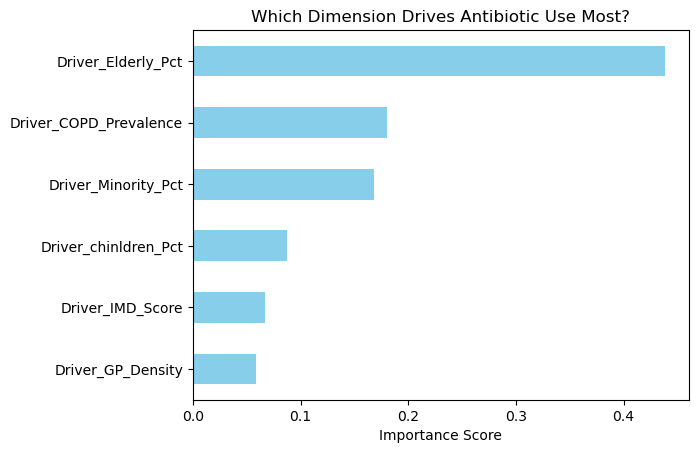

In [11]:
importances = pd.Series(UK_Sub.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', color='skyblue')
plt.title('Which Dimension Drives Antibiotic Use Most?')
plt.xlabel('Importance Score')
plt.savefig('02_features_importance.png')

In [12]:
import shap

/opt/anaconda3/envs/ds/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
explainer = shap.TreeExplainer(UK_Sub)
shap_values = explainer.shap_values(X)

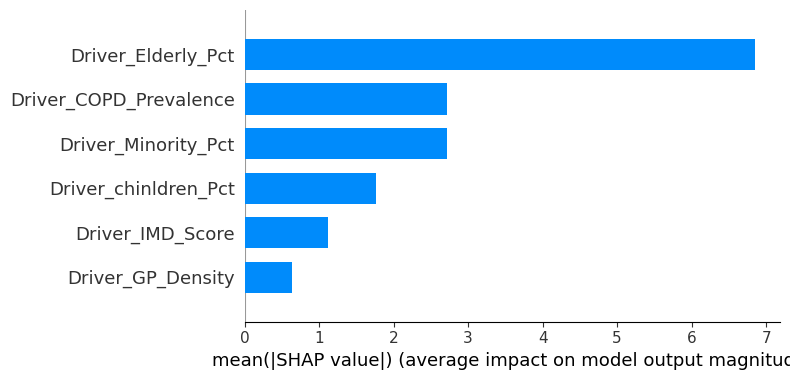

In [20]:
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X, plot_type='bar',show=False)
plt.savefig('UK_SUB_SHAP_bar.png')


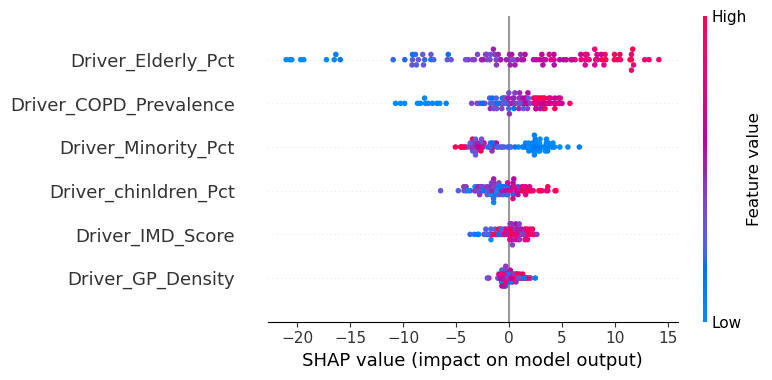

In [21]:
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X, show=False)
plt.savefig('UK_SUB_SHAP_dot.png')


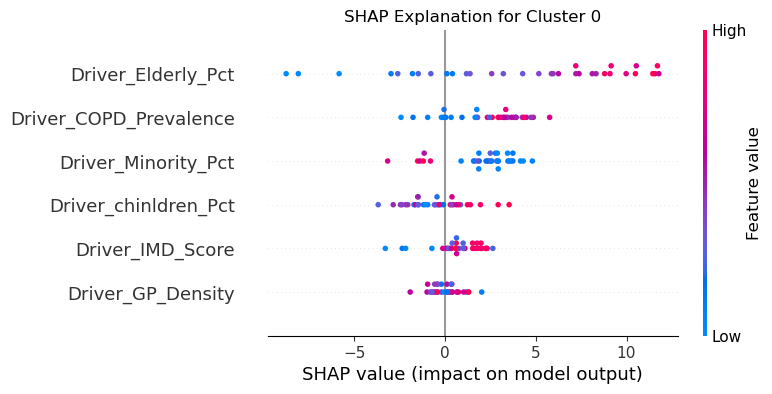

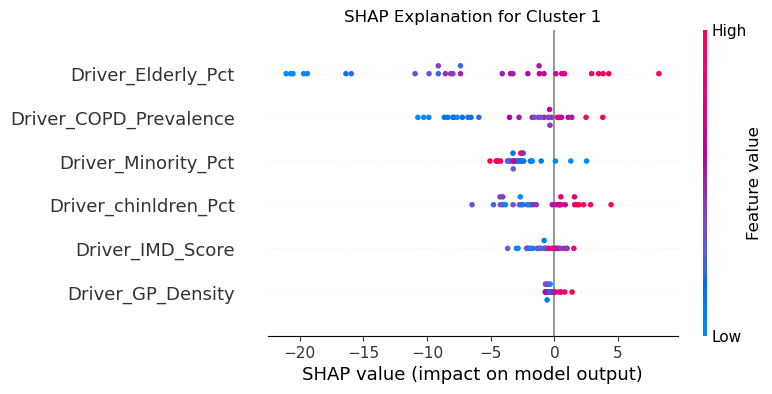

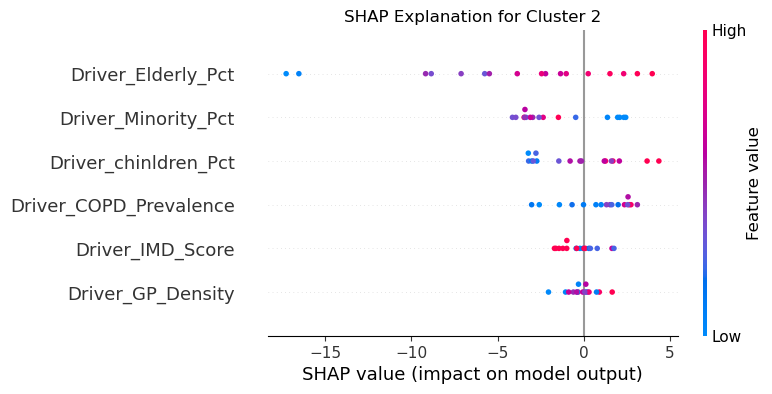

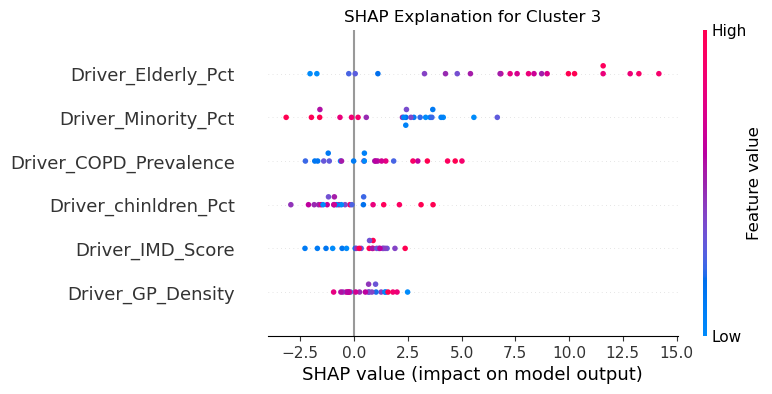

In [25]:
for i in range(4):
    cluster_indices = df[df['Cluster'] == i].index
    cluster_shap = shap_values[cluster_indices]
    cluster_X = X.iloc[cluster_indices]

    plt.figure(figsize=(10,6))
    shap.summary_plot(cluster_shap,cluster_X,show=False)
    plt.title(f'SHAP Explanation for Cluster {i}')
    file_name = f'04_cluster_{i}_SHAP_dot.png'
    plt.savefig(file_name)
